# BioTemporal-HAR Training Notebook

This notebook implements the runnable part of the BioTemporal-HAR proposal using the CSV files checked into `data/`. The available files contain one accelerometer stream (`acc_x`, `acc_y`, `acc_z`), timestamps, and activity labels. Because this local schema does not include subject IDs, phone/watch device IDs, or gyroscope channels, the notebook trains and evaluates the activity-recognition pipeline and uses Signal Detection Theory (SDT) style one-vs-rest calibration for activity decisions. The biometric identity and multi-sensor fusion sections are left as guarded extension points that activate only when those columns are available.


## 1. Setup

The model follows the proposal's compact CNN-LSTM architecture. PyTorch is used because it is installed in this environment, while TensorFlow is not.

In [1]:
from pathlib import Path
import json
import math
import pickle
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "train.csv").exists()),
    Path.cwd(),
)
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

LABEL_COL = "Activity"
TIMESTAMP_COL = "timestamp"

# WISDM-style 20 Hz sampling: 51 samples is about 2.55 seconds.
WINDOW_SIZE = 51
STRIDE = 25
MAX_GAP_SECONDS = 1.0

VALIDATION_SIZE = 0.20
MAX_TRAIN_WINDOWS = 50_000
MAX_VAL_WINDOWS = 12_000
MAX_TEST_WINDOWS = 15_000

RUN_CLASSICAL_BASELINE = True
EPOCHS = 5
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
TARGET_FALSE_ALARM_RATE = 0.01

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Using device: cpu
PyTorch: 2.9.0+cpu


## 2. Load and Inspect the Local Data

The proposal describes the full WISDM Smartphone and Smartwatch Activity and Biometrics dataset. This repository currently contains already-split CSV files with six numeric activity classes and one tri-axial accelerometer stream.

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

required = {"acc_x", "acc_y", "acc_z", TIMESTAMP_COL, LABEL_COL}
missing = required.difference(train_df.columns)
if missing:
    raise ValueError(f"Missing required training columns: {sorted(missing)}")

numeric_cols = [
    c for c in train_df.columns
    if c not in {LABEL_COL, TIMESTAMP_COL}
    and pd.api.types.is_numeric_dtype(train_df[c])
]
feature_cols = [c for c in numeric_cols if c in test_df.columns]

subject_candidates = ["subject", "subject_id", "user", "user_id", "participant", "participant_id"]
device_candidates = ["device", "sensor", "source", "position", "watch_phone"]
subject_col = next((c for c in subject_candidates if c in train_df.columns), None)
device_col = next((c for c in device_candidates if c in train_df.columns), None)
gyro_cols = [c for c in feature_cols if c.lower().startswith(("gyro", "gyr"))]
acc_cols = [c for c in feature_cols if c.lower().startswith("acc")]

def describe_split(name, df):
    display(pd.DataFrame({
        "rows": [len(df)],
        "columns": [len(df.columns)],
        "activity_classes": [df[LABEL_COL].nunique()],
        "timestamp_min": [df[TIMESTAMP_COL].min()],
        "timestamp_max": [df[TIMESTAMP_COL].max()],
    }, index=[name]))
    display(df[LABEL_COL].value_counts().sort_index().rename("count").to_frame())

print("Feature columns:", feature_cols)
print("Accelerometer columns:", acc_cols)
print("Gyroscope columns:", gyro_cols if gyro_cols else "not present")
print("Subject column:", subject_col if subject_col else "not present")
print("Device column:", device_col if device_col else "not present")
describe_split("train.csv", train_df)
describe_split("test.csv", test_df)

Feature columns: ['acc_x', 'acc_y', 'acc_z']
Accelerometer columns: ['acc_x', 'acc_y', 'acc_z']
Gyroscope columns: not present
Subject column: not present
Device column: not present


,rows,columns,activity_classes,timestamp_min,timestamp_max
train.csv,860752,5,6,0.0,209397.3615


,count
Activity,
0,79642
1,273579
2,49853
3,40217
4,92754
5,324707


,rows,columns,activity_classes,timestamp_min,timestamp_max
test.csv,225713,5,6,0.0,209014.8515


,count
Activity,
0,20783
1,62866
2,10086
3,8177
4,30115
5,93686


## 3. Windowing Without Crossing Temporal Breaks

The notebook creates fixed-length windows inside contiguous regions. A new segment starts whenever the timestamp resets, jumps by more than one second, or the activity label changes. Validation is then split by segment ID to avoid placing overlapping windows from the same local time region into both train and validation sets.

In [3]:
def add_segment_ids(df, timestamp_col=TIMESTAMP_COL, label_col=LABEL_COL, max_gap_seconds=MAX_GAP_SECONDS):
    df = df.reset_index(drop=True).copy()
    if len(df) == 0:
        df["_segment_id"] = []
        return df

    timestamps = df[timestamp_col].to_numpy()
    labels = df[label_col].to_numpy()
    breaks = np.ones(len(df), dtype=bool)
    if len(df) > 1:
        dt = np.diff(timestamps)
        label_changed = labels[1:] != labels[:-1]
        breaks[1:] = (dt <= 0) | (dt > max_gap_seconds) | label_changed
    df["_segment_id"] = np.cumsum(breaks) - 1
    return df


def build_windows(df, feature_columns, window_size=WINDOW_SIZE, stride=STRIDE):
    segmented = add_segment_ids(df)
    windows, labels, groups = [], [], []
    segment_lengths = []

    for segment_id, segment in segmented.groupby("_segment_id", sort=False):
        segment_lengths.append(len(segment))
        if len(segment) < window_size:
            continue

        values = segment[feature_columns].to_numpy(dtype=np.float32)
        label = segment[LABEL_COL].iloc[0]
        for start in range(0, len(segment) - window_size + 1, stride):
            windows.append(values[start:start + window_size])
            labels.append(label)
            groups.append(segment_id)

    if not windows:
        raise ValueError("No windows were created. Lower WINDOW_SIZE or inspect timestamp segmentation.")

    stats = {
        "segments": len(segment_lengths),
        "segments_long_enough": int(np.sum(np.array(segment_lengths) >= window_size)),
        "median_segment_length": float(np.median(segment_lengths)),
        "max_segment_length": int(np.max(segment_lengths)),
    }
    return (
        np.stack(windows).astype(np.float32),
        np.array(labels),
        np.array(groups),
        stats,
    )


def stratified_cap(indices, labels, max_count, seed=SEED):
    indices = np.asarray(indices)
    if max_count is None or len(indices) <= max_count:
        return indices
    try:
        selected, _ = train_test_split(
            indices,
            train_size=max_count,
            random_state=seed,
            stratify=labels[indices],
        )
        return np.asarray(selected)
    except ValueError:
        rng = np.random.default_rng(seed)
        return rng.choice(indices, size=max_count, replace=False)


X_all, y_all_raw, groups_all, train_window_stats = build_windows(train_df, feature_cols)
X_test_raw, y_test_raw, test_groups, test_window_stats = build_windows(test_df, feature_cols)

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_all_raw)
known_test_mask = np.isin(y_test_raw, label_encoder.classes_)
X_test_raw = X_test_raw[known_test_mask]
y_test = label_encoder.transform(y_test_raw[known_test_mask])

splitter = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(X_all, y_all, groups_all))
train_idx = stratified_cap(train_idx, y_all, MAX_TRAIN_WINDOWS, SEED)
val_idx = stratified_cap(val_idx, y_all, MAX_VAL_WINDOWS, SEED + 1)
test_idx = stratified_cap(np.arange(len(X_test_raw)), y_test, MAX_TEST_WINDOWS, SEED + 2)

X_train_raw, y_train = X_all[train_idx], y_all[train_idx]
X_val_raw, y_val = X_all[val_idx], y_all[val_idx]
X_test_raw, y_test = X_test_raw[test_idx], y_test[test_idx]

print("Train windowing stats:", train_window_stats)
print("Test windowing stats:", test_window_stats)
print("Window tensor shapes:")
print("  train", X_train_raw.shape, "val", X_val_raw.shape, "test", X_test_raw.shape)
print("Classes:", label_encoder.classes_.tolist())

Train windowing stats: {'segments': 47478, 'segments_long_enough': 5578, 'median_segment_length': 2.0, 'max_segment_length': 2977}
Test windowing stats: {'segments': 15252, 'segments_long_enough': 1426, 'median_segment_length': 2.0, 'max_segment_length': 2887}
Window tensor shapes:
  train (13506, 51, 3) val (3271, 51, 3) test (4521, 51, 3)
Classes: [0, 1, 2, 3, 4, 5]


## 4. Scale the Sensor Channels

The scaler is fit only on training windows, then applied to validation and test windows.

In [4]:
def fit_window_scaler(X):
    scaler = StandardScaler()
    scaler.fit(X.reshape(-1, X.shape[-1]))
    return scaler


def transform_windows(X, scaler):
    shape = X.shape
    return scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype(np.float32)


scaler = fit_window_scaler(X_train_raw)
X_train = transform_windows(X_train_raw, scaler)
X_val = transform_windows(X_val_raw, scaler)
X_test = transform_windows(X_test_raw, scaler)

pd.DataFrame(X_train.reshape(-1, X_train.shape[-1]), columns=feature_cols).describe().loc[["mean", "std"]]

,acc_x,acc_y,acc_z
mean,8.916389e-09,-9.126839e-09,4.341894e-09
std,1.000001e+00,1.000001e+00,1.000001e+00


## 5. Feature Baseline With Mutual Information Selection

This lightweight baseline supports the proposal's feature-selection comparison. It computes time-domain features per window, selects the most informative features using mutual information, and trains a balanced random forest.

In [5]:
def window_feature_table(X, columns):
    features = {}
    for i, column in enumerate(columns):
        values = X[:, :, i]
        features[f"{column}_mean"] = values.mean(axis=1)
        features[f"{column}_std"] = values.std(axis=1)
        features[f"{column}_min"] = values.min(axis=1)
        features[f"{column}_max"] = values.max(axis=1)
        features[f"{column}_median"] = np.median(values, axis=1)
        features[f"{column}_energy"] = np.mean(values ** 2, axis=1)

    magnitude = np.linalg.norm(X, axis=2)
    features["magnitude_mean"] = magnitude.mean(axis=1)
    features["magnitude_std"] = magnitude.std(axis=1)
    features["magnitude_energy"] = np.mean(magnitude ** 2, axis=1)
    features["magnitude_range"] = magnitude.max(axis=1) - magnitude.min(axis=1)

    if X.shape[-1] >= 2:
        for i in range(X.shape[-1]):
            for j in range(i + 1, X.shape[-1]):
                a = X[:, :, i]
                b = X[:, :, j]
                numerator = ((a - a.mean(axis=1, keepdims=True)) * (b - b.mean(axis=1, keepdims=True))).mean(axis=1)
                denominator = a.std(axis=1) * b.std(axis=1) + 1e-8
                features[f"corr_{columns[i]}_{columns[j]}"] = numerator / denominator
    return pd.DataFrame(features)


baseline_results = None
selected_feature_names = []
if RUN_CLASSICAL_BASELINE:
    X_train_feat = window_feature_table(X_train, feature_cols)
    X_val_feat = window_feature_table(X_val, feature_cols)
    X_test_feat = window_feature_table(X_test, feature_cols)

    mi = mutual_info_classif(X_train_feat, y_train, random_state=SEED)
    mi_series = pd.Series(mi, index=X_train_feat.columns).sort_values(ascending=False)
    top_k = min(16, len(mi_series))
    selected_feature_names = mi_series.head(top_k).index.tolist()

    rf = RandomForestClassifier(
        n_estimators=150,
        random_state=SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
        min_samples_leaf=2,
    )
    rf.fit(X_train_feat[selected_feature_names], y_train)
    val_pred = rf.predict(X_val_feat[selected_feature_names])
    test_pred = rf.predict(X_test_feat[selected_feature_names])

    baseline_results = {
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_macro_f1": f1_score(y_test, test_pred, average="macro"),
    }
    print("Selected features:")
    display(mi_series.head(top_k).rename("mutual_information").to_frame())
    print("Random forest baseline:")
    display(pd.DataFrame([baseline_results]))
else:
    print("Classical feature baseline skipped.")

Selected features:


,mutual_information
acc_y_std,0.713459
acc_y_energy,0.695332
acc_y_min,0.621779
acc_x_std,0.620280
magnitude_energy,0.598677
magnitude_mean,0.589042
acc_z_std,0.537554
acc_z_min,0.504976
magnitude_std,0.501372
acc_y_max,0.458057


Random forest baseline:


,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,0.907368,0.879733,0.743862,0.729315


## 6. Compact CNN-LSTM Model

The convolutional layers learn local temporal motion patterns. The LSTM summarizes the ordered window representation before the activity classifier head.

In [6]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.y = torch.from_numpy(np.asarray(y, dtype=np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class CompactCNNLSTM(nn.Module):
    def __init__(self, n_channels, n_classes, conv_channels=64, hidden_size=64, dropout=0.25):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, conv_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_classes),
        )

    def forward(self, x):
        # x: batch, time, channels
        z = x.transpose(1, 2)
        z = self.conv(z).transpose(1, 2)
        lstm_out, _ = self.lstm(z)
        return self.classifier(lstm_out[:, -1, :])


def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WindowDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(WindowDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

n_classes = len(label_encoder.classes_)
model = CompactCNNLSTM(n_channels=X_train.shape[-1], n_classes=n_classes).to(DEVICE)
print(model)
print(f"Trainable parameters: {parameter_count(model):,}")

CompactCNNLSTM(
  (conv): Sequential(
    (0): Conv1d(3, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.25, inplace=False)
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.25, inplace=False)
    (1): Linear(in_features=64, out_features=6, bias=True)
  )
)
Trainable parameters: 40,582


In [7]:
def evaluate_model(model, loader, criterion=None):
    model.eval()
    losses, logits_all, y_all_eval = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            if criterion is not None:
                losses.append(criterion(logits, y_batch).item())
            logits_all.append(logits.cpu().numpy())
            y_all_eval.append(y_batch.cpu().numpy())

    logits = np.concatenate(logits_all)
    y_true = np.concatenate(y_all_eval)
    y_pred = logits.argmax(axis=1)
    return {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "logits": logits,
        "y_true": y_true,
    }


class_counts = np.bincount(y_train, minlength=n_classes)
class_weights = len(y_train) / (n_classes * np.maximum(class_counts, 1))
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = []
best_state = None
best_macro_f1 = -math.inf
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        train_losses.append(loss.item())

    val_metrics = evaluate_model(model, val_loader, criterion)
    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
    }
    history.append(row)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={row['train_loss']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"val_acc={row['val_accuracy']:.4f} | "
        f"val_macro_f1={row['val_macro_f1']:.4f}"
    )

    if row["val_macro_f1"] > best_macro_f1:
        best_macro_f1 = row["val_macro_f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

elapsed = time.time() - start_time
history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACT_DIR / "training_metrics.csv", index=False)
print(f"Training finished in {elapsed:.1f} seconds. Best validation macro F1: {best_macro_f1:.4f}")
display(history_df)

Epoch 01/5 | train_loss=1.2370 | val_loss=0.8167 | val_acc=0.7487 | val_macro_f1=0.6695


Epoch 02/5 | train_loss=0.6541 | val_loss=0.5730 | val_acc=0.7894 | val_macro_f1=0.7625


Epoch 03/5 | train_loss=0.4893 | val_loss=0.4943 | val_acc=0.8236 | val_macro_f1=0.8012


Epoch 04/5 | train_loss=0.4114 | val_loss=0.4151 | val_acc=0.8581 | val_macro_f1=0.8365


Epoch 05/5 | train_loss=0.3497 | val_loss=0.3822 | val_acc=0.8851 | val_macro_f1=0.8511
Training finished in 19.3 seconds. Best validation macro F1: 0.8511


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1
0,1,1.236982,0.816706,0.748701,0.669501
1,2,0.654141,0.573004,0.789361,0.762473
2,3,0.489276,0.494297,0.823601,0.801195
3,4,0.411450,0.415060,0.858147,0.836538
4,5,0.349690,0.382153,0.885050,0.851078


## 7. Test Evaluation

The held-out `data/test.csv` split is used only after model selection on the validation windows.

CNN-LSTM test accuracy: 0.8045
CNN-LSTM test macro F1: 0.7504
              precision    recall  f1-score   support

           0     0.6867    0.3756    0.4856       426
           1     0.9776    0.9059    0.9404       914
           2     0.7342    0.6237    0.6744        93
           3     0.7927    1.0000    0.8844       153
           4     0.4976    0.9203    0.6460       690
           5     0.9525    0.8031    0.8714      2245

    accuracy                         0.8045      4521
   macro avg     0.7735    0.7714    0.7504      4521
weighted avg     0.8532    0.8045    0.8110      4521



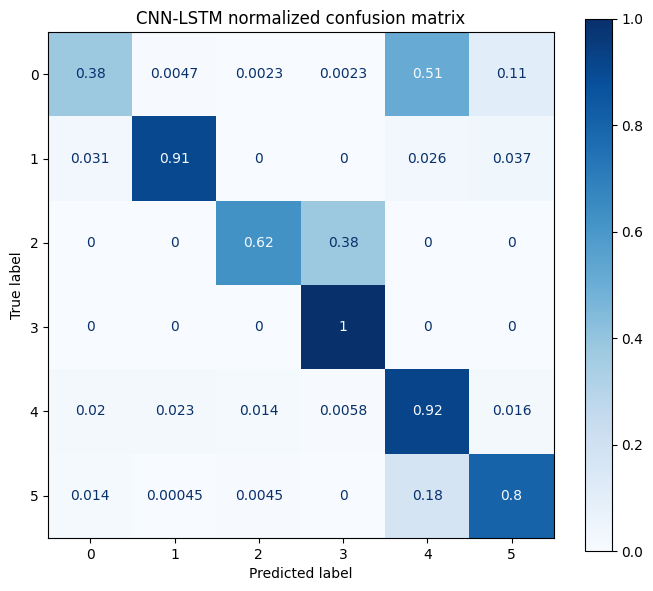

In [8]:
test_metrics = evaluate_model(model, test_loader, criterion)
test_logits = test_metrics["logits"]
test_probs = torch.softmax(torch.from_numpy(test_logits), dim=1).numpy()
test_pred = test_probs.argmax(axis=1)

print(f"CNN-LSTM test accuracy: {test_metrics['accuracy']:.4f}")
print(f"CNN-LSTM test macro F1: {test_metrics['macro_f1']:.4f}")
print(classification_report(
    y_test,
    test_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    digits=4,
))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=[str(c) for c in label_encoder.classes_],
    cmap="Blues",
    normalize="true",
    ax=ax,
)
ax.set_title("CNN-LSTM normalized confusion matrix")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 8. SDT-Style Threshold Calibration

The proposal's identity-verification SDT calibration needs subject IDs and genuine/impostor identity claims. Since the present CSVs contain only activities, this section applies the same detection math to one-vs-rest activity scores: each class is treated as a signal class and all other classes as noise. Thresholds are selected on validation scores to target a low false alarm rate, then evaluated on the held-out test set.

In [9]:
def sdt_counts(scores, labels, positive_class, threshold):
    is_signal = labels == positive_class
    accepts = scores >= threshold
    hits = int(np.sum(accepts & is_signal))
    misses = int(np.sum((~accepts) & is_signal))
    false_alarms = int(np.sum(accepts & (~is_signal)))
    correct_rejections = int(np.sum((~accepts) & (~is_signal)))
    return hits, misses, false_alarms, correct_rejections


def sdt_from_counts(hits, misses, false_alarms, correct_rejections):
    signal_n = hits + misses
    noise_n = false_alarms + correct_rejections
    hit_rate = (hits + 0.5) / (signal_n + 1.0)
    false_alarm_rate = (false_alarms + 0.5) / (noise_n + 1.0)
    miss_rate = 1.0 - hit_rate
    z_hit = norm.ppf(hit_rate)
    z_fa = norm.ppf(false_alarm_rate)
    d_prime = z_hit - z_fa
    criterion = -0.5 * (z_hit + z_fa)
    return {
        "hit_rate": hit_rate,
        "false_alarm_rate": false_alarm_rate,
        "miss_rate": miss_rate,
        "d_prime": d_prime,
        "criterion": criterion,
    }


val_logits = evaluate_model(model, val_loader)["logits"]
val_probs = torch.softmax(torch.from_numpy(val_logits), dim=1).numpy()

sdt_rows = []
for class_idx, class_label in enumerate(label_encoder.classes_):
    non_target_scores = val_probs[y_val != class_idx, class_idx]
    threshold = float(np.quantile(non_target_scores, 1.0 - TARGET_FALSE_ALARM_RATE))

    val_counts = sdt_counts(val_probs[:, class_idx], y_val, class_idx, threshold)
    test_counts = sdt_counts(test_probs[:, class_idx], y_test, class_idx, threshold)
    val_metrics = sdt_from_counts(*val_counts)
    heldout_metrics = sdt_from_counts(*test_counts)

    sdt_rows.append({
        "class_label": class_label,
        "threshold": threshold,
        "target_false_alarm_rate": TARGET_FALSE_ALARM_RATE,
        "val_hit_rate": val_metrics["hit_rate"],
        "val_false_alarm_rate": val_metrics["false_alarm_rate"],
        "test_hit_rate": heldout_metrics["hit_rate"],
        "test_false_alarm_rate": heldout_metrics["false_alarm_rate"],
        "test_miss_rate": heldout_metrics["miss_rate"],
        "test_d_prime": heldout_metrics["d_prime"],
        "test_criterion": heldout_metrics["criterion"],
    })

sdt_df = pd.DataFrame(sdt_rows)
sdt_df.to_csv(ARTIFACT_DIR / "sdt_activity_thresholds.csv", index=False)
display(sdt_df)

,class_label,threshold,target_false_alarm_rate,val_hit_rate,val_false_alarm_rate,test_hit_rate,test_false_alarm_rate,test_miss_rate,test_d_prime,test_criterion
0,0,0.573393,0.01,0.341270,0.010311,0.272834,0.006470,0.727166,1.881166,1.544848
1,1,0.612177,0.01,0.975768,0.010507,0.867213,0.004296,0.132787,3.741188,0.757281
2,2,0.010903,0.01,0.931193,0.010272,0.622340,0.032626,0.377660,2.155163,0.765948
3,3,0.012227,0.01,0.997175,0.010174,0.996753,0.029641,0.003247,4.607862,-0.417830
4,4,0.750548,0.01,0.340506,0.010250,0.327786,0.072938,0.672214,1.008215,0.950143
5,5,0.783145,0.01,0.872125,0.010609,0.745102,0.028766,0.254898,2.558405,0.620046


## 9. Proposal Extension Points

These checks document which proposal components can be run from the present CSV schema and which need richer WISDM metadata.

In [10]:
if subject_col is None:
    print("Closed-set identity and identity verification are skipped: no subject ID column is present.")
else:
    print(f"Subject column found: {subject_col}. Train a second classifier head with this target for identity.")

if device_col is None or not gyro_cols:
    print("Phone/watch fusion and accelerometer+gyroscope ablations are skipped: device/gyro columns are not present.")
else:
    print(f"Fusion-ready columns found: device={device_col}, gyro={gyro_cols}.")

print("Runnable proposal components completed:")
print("- leakage-conscious windowing")
print("- feature-selection baseline")
print("- compact CNN-LSTM training")
print("- held-out test evaluation")
print("- SDT-style threshold calibration")

Closed-set identity and identity verification are skipped: no subject ID column is present.
Phone/watch fusion and accelerometer+gyroscope ablations are skipped: device/gyro columns are not present.
Runnable proposal components completed:
- leakage-conscious windowing
- feature-selection baseline
- compact CNN-LSTM training
- held-out test evaluation
- SDT-style threshold calibration


## 10. Save Reproducible Artifacts

The model checkpoint stores the feature columns, window parameters, class labels, and learned PyTorch weights. The scaler and label encoder are saved separately with pickle.

In [11]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_class": "CompactCNNLSTM",
    "feature_cols": feature_cols,
    "classes": label_encoder.classes_.tolist(),
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "max_gap_seconds": MAX_GAP_SECONDS,
    "n_channels": X_train.shape[-1],
    "n_classes": n_classes,
    "parameter_count": parameter_count(model),
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "baseline_results": baseline_results,
    "selected_feature_names": selected_feature_names,
}

torch.save(checkpoint, ARTIFACT_DIR / "biotemporal_cnn_lstm.pt")
with open(ARTIFACT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACT_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open(ARTIFACT_DIR / "window_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "feature_cols": feature_cols,
        "window_size": WINDOW_SIZE,
        "stride": STRIDE,
        "max_gap_seconds": MAX_GAP_SECONDS,
        "classes": [str(c) for c in label_encoder.classes_.tolist()],
    }, f, indent=2)

print("Saved artifacts:")
for path in sorted(ARTIFACT_DIR.glob("*")):
    print("-", path)

Saved artifacts:
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\biotemporal_cnn_lstm.pt
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\confusion_matrix.png
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\label_encoder.pkl
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\scaler.pkl
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\sdt_activity_thresholds.csv
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\training_metrics.csv
- C:\Users\Louis\Documents\GitHub\BioTemporal-HAR\artifacts\window_config.json
